In [80]:
import os, sys
project_root = os.path.dirname(os.getcwd())
if project_root not in sys.path:
    sys.path.insert(0, project_root)
# print(project_root)

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from src.data_ingestion import load_data_from_gcs, SERVICE_ACCOUNT_PATH, bucket_name, blob_name

%matplotlib inline
sns.set_theme(style="whitegrid", palette="muted")

PALETTE = {"positive": "#0D7BDB", "neutral": "#15CC6E", "negative": "#A30F0F"}

# from google.cloud import storage
# storage_client = storage.Client.from_service_account_json(SERVICE_ACCOUNT_PATH)
# bucket = storage_client.bucket(bucket_name)






In [81]:
import traceback
import importlib, src.data_ingestion as _di
importlib.reload(_di)

from src.data_ingestion import load_data_from_gcs, SERVICE_ACCOUNT_PATH, bucket_name, blob_name

try:
    df = load_data_from_gcs("cleaned_reviews.csv")
    display(df.head())

except Exception as e:
    print(f"Error occured while downloading the dataset: {e}")
    traceback.print_exc()


try:
    from google.cloud import storage
    storage_client = storage.Client.from_service_account_json(SERVICE_ACCOUNT_PATH)
    bucket = storage_client.bucket(bucket_name)
    blobs = list(bucket.list_blobs(prefix="raw_data/"))
    print("Bucket blobs:", [b for b in blobs])

except Exception as e:
    print(f"Could not list the blobs via storage client, {e}")
    



Downloaded file to: C:\Users\PRIYAB~1\AppData\Local\Temp\cleaned_reviews.csv


,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0


Bucket blobs: [<Blob: machine_learning_datasets, raw_data/, 1775895585254025>, <Blob: machine_learning_datasets, raw_data/cleaned_reviews.csv, 1778674536071842>, <Blob: machine_learning_datasets, raw_data/retail_store_inventory.csv, 1775895645530933>]


In [82]:
df

,sentiments,cleaned_review,cleaned_review_length,review_score
0,positive,i wish would have gotten one earlier love it a...,19,5.0
1,neutral,i ve learned this lesson again open the packag...,88,1.0
2,neutral,it is so slow and lags find better option,9,2.0
3,neutral,roller ball stopped working within months of m...,12,1.0
4,neutral,i like the color and size but it few days out ...,21,1.0
...,...,...,...,...
17335,positive,i love this speaker and love can take it anywh...,30,5.0
17336,positive,i use it in my house easy to connect and loud ...,13,4.0
17337,positive,the bass is good and the battery is amazing mu...,41,5.0
17338,positive,love it,2,5.0


In [83]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17340 entries, 0 to 17339
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sentiments             17340 non-null  str    
 1   cleaned_review         17337 non-null  str    
 2   cleaned_review_length  17340 non-null  int64  
 3   review_score           17340 non-null  float64
dtypes: float64(1), int64(1), str(2)
memory usage: 3.3 MB


In [84]:
df.isnull().sum()

sentiments               0
cleaned_review           3
cleaned_review_length    0
review_score             0
dtype: int64

In [85]:
df.describe()

,cleaned_review_length,review_score
count,17340.000000,17340.000000
mean,30.300461,3.649077
std,35.836540,1.673500
min,0.000000,1.000000
25%,9.000000,2.000000
50%,20.000000,5.000000
75%,38.000000,5.000000
max,571.000000,5.000000


In [86]:
counts = df['sentiments'].value_counts()

In [87]:
counts

sentiments
positive    9503
neutral     6303
negative    1534
Name: count, dtype: int64

In [88]:
pct = counts/len(df) * 100

In [89]:
pct

sentiments
positive    54.803922
neutral     36.349481
negative     8.846597
Name: count, dtype: float64

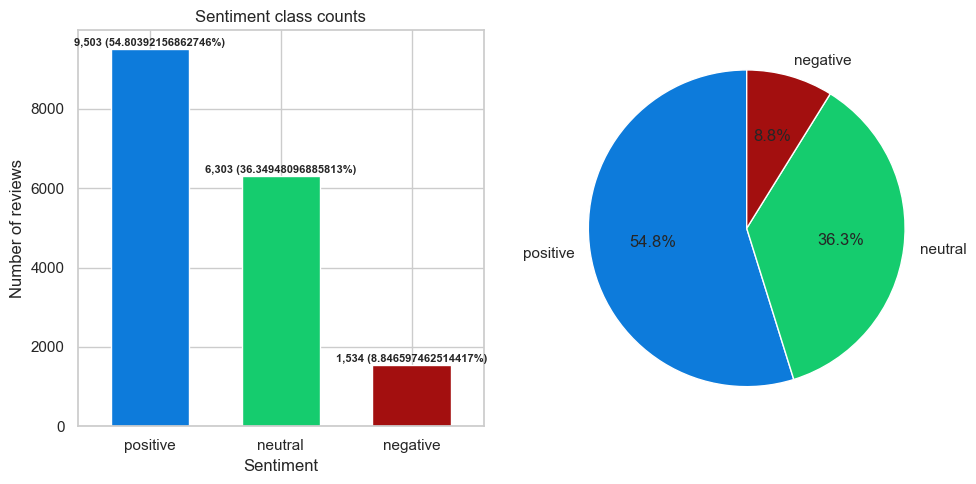

In [95]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

colors = [PALETTE[s] for s in counts.index]
counts.plot(kind="bar", ax=axes[0], color=colors, edgecolor="white", width=0.6)
axes[0].set_title("Sentiment class counts")
axes[0].set_xlabel("Sentiment")
axes[0].set_ylabel("Number of reviews")
axes[0].tick_params(axis='x', rotation=0)

for i, (v, p) in enumerate(zip(counts, pct)):
    axes[0].text(i, v + 80, f'{v:,} ({p}%)', ha="center", fontsize=8, fontweight="bold")

# pie chart

axes[1].pie(counts, labels=counts.index, autopct="%1.1f%%", colors=colors, startangle=90, )
# axes.set_title("Sentiment proportion")

plt.tight_layout()
plt.show()
    



In [96]:
df['review_score']

0        5.0
1        1.0
2        2.0
3        1.0
4        1.0
        ... 
17335    5.0
17336    4.0
17337    5.0
17338    5.0
17339    5.0
Name: review_score, Length: 17340, dtype: float64

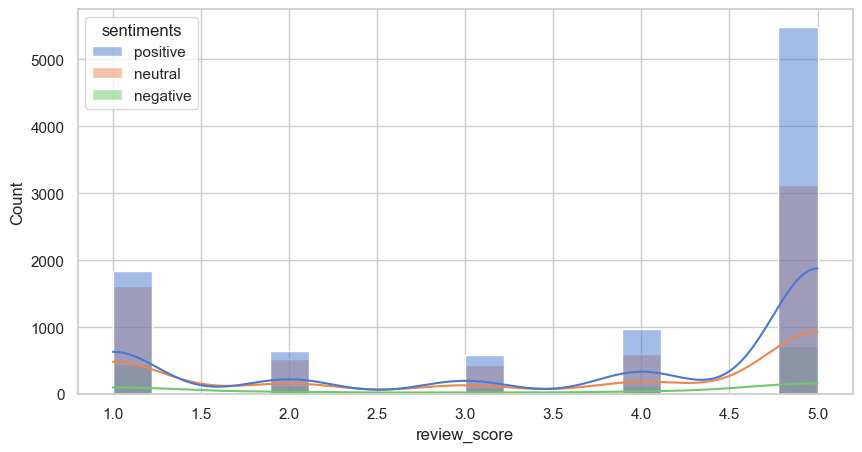

In [99]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x="review_score", kde=True, hue="sentiments")
# plt.xlabel("dist of reviews")
plt.show()

In [100]:
df['cleaned_review_length']

0        19
1        88
2         9
3        12
4        21
         ..
17335    30
17336    13
17337    41
17338     2
17339     2
Name: cleaned_review_length, Length: 17340, dtype: int64

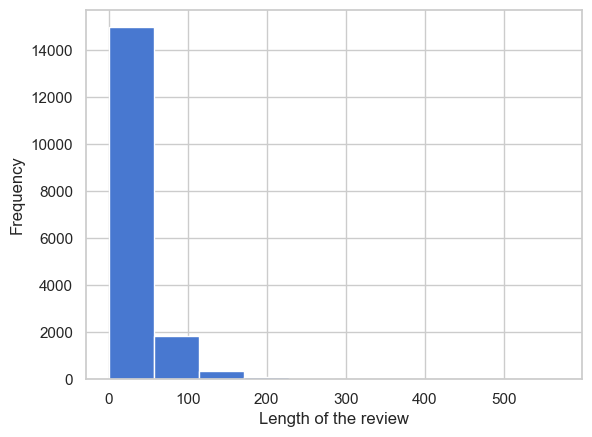

In [102]:
df['cleaned_review_length'].plot(kind="hist")
plt.xlabel("Length of the review")
plt.show()